<div align="center">

# **Sleep Health Analysis & Classification**
### **Machine Learning Project (KNN Algorithm)**

---

**Student Name:** Waleed zohud

**Supervised by:** [Dr.nedal altamimi]  
**Department:** Data Science & AI  

---

### **Project Overview**
This project applies the **K-Nearest Neighbors (KNN)** algorithm to classify sleep disorders and analyze sleep quality based on lifestyle habits such as physical activity, stress levels, and cardiovascular health.

### **Tech Stack**
* **Language:** Python
* **Libraries:** Pandas, Scikit-learn, Seaborn, Matplotlib
* **Dataset:** Sleep Health and Lifestyle Dataset

---

</div>

#Step 1: Data Loading & Initial Exploration

In [ ]:
import pandas as pd

# 1) Load the 'Sleep_health_and_lifestyle_dataset.csv' file using pandas
df = pd.read_csv('/content/Sleep_health_and_lifestyle_dataset.csv')

#Step 2: Dataset Dimensions

In [ ]:
# 2) Print the number of rows and columns (shape)
print(f"Dataset shape (rows, columns): {df.shape}")

Dataset shape (rows, columns): (374, 13)


#Step 3: Total Instances Count

In [ ]:
# 3) Print the total number of instances
print(f"Total number of instances (rows): {len(df)}")

Total number of instances (rows): 374


#Step 4: Data Inspection & Technical Summary

In [ ]:
# 4) Display the first 5 rows
print("\nFirst 5 rows of the dataset:")
display(df.head())

# 4) Display a summary of the data types using df.info()
print("\nSummary of data types and non-null values:")
df.info()


First 5 rows of the dataset:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea



Summary of data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
m

#Step 5: Data Preprocessing & Feature Engineering

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Check if 'Blood Pressure' column exists before processing
if 'Blood Pressure' in df.columns:
    # Split 'Blood Pressure' into 'Systolic' and 'Diastolic' and convert to int
    df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
    # Drop the original 'Blood Pressure' column
    df.drop('Blood Pressure', axis=1, inplace=True)

# Fill missing values in 'Sleep Disorder' with 'None'
df['Sleep Disorder'].fillna('None', inplace=True)

# Convert categorical columns to numerical using LabelEncoder
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

# Display the first 5 rows of the updated dataframe
print("\nFirst 5 rows of the updated dataframe:")
display(df.head())


First 5 rows of the updated dataframe:


/tmp/ipykernel_1481/4199480580.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sleep Disorder'].fillna('None', inplace=True)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,1,27,9,6.1,6,42,6,3,77,4200,1,126,83
1,2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
2,3,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
3,4,1,28,6,5.9,4,30,8,2,85,3000,2,140,90
4,5,1,28,6,5.9,4,30,8,2,85,3000,2,140,90


#Step 6: Model Training & Performance Evaluation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Set 'Sleep Disorder' as the target variable (y) and all other columns as features (X)
X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply StandardScaler to scale the features (X_train and X_test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the KNN classifier with n_neighbors=5
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Train it on the training data
knn_classifier.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = knn_classifier.predict(X_test_scaled)

# Print the accuracy score on the test set
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Classifier Accuracy: {accuracy:.4f}")

KNN Classifier Accuracy: 0.8667


#Step 7: Model Evaluation & Performance Metrics

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Print Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[13  1  2]
 [ 2 41  0]
 [ 4  1 11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.81      0.74        16
           1       0.95      0.95      0.95        43
           2       0.85      0.69      0.76        16

    accuracy                           0.87        75
   macro avg       0.83      0.82      0.82        75
weighted avg       0.87      0.87      0.87        75



#Step 8: Visualizing the Confusion Matrix (Heatmap)

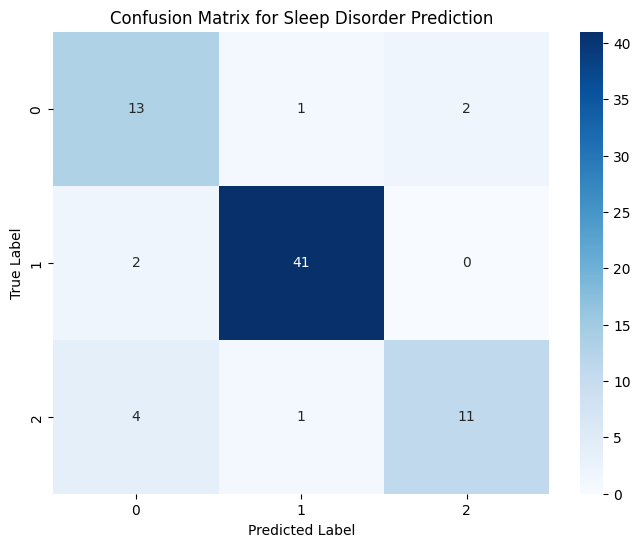

In [ ]:
# Plotting the Confusion Matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix for Sleep Disorder Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 🏆 **Project Milestone: Intelligent Sleep Disorder Diagnostics**
## *Leveraging Machine Learning (KNN) for Health & Lifestyle Analysis*

---

## 🌐 **1. Strategic Vision & Core Purpose**
The primary objective of this project is to transform raw health data into actionable medical insights. By analyzing the complex interplay between **Cardiovascular Health**, **Physical Activity**, and **Psychological Stress**, we built a predictive engine that identifies sleep pathologies at an early stage.

**The Vision:** Moving from "Reactive" to "Proactive" healthcare through AI-driven personalized diagnostics.

---

## 🛠️ **2. The Tech Stack (Our Digital Toolkit)**
| Category | Tools | Purpose |
| :--- | :--- | :--- |
| **Language** | `Python 3.x` | Core computational engine |
| **Analysis** | `Pandas & NumPy` | Data cleaning, reshaping, and engineering |
| **AI Engine** | `Scikit-Learn` | Implementing KNN, Scaling, and Encoding |
| **Visuals** | `Seaborn & Matplotlib` | Transforming numbers into intuitive heatmaps |

---

## ⚙️ **3. Technical Execution Roadmap**

### 🧬 **A. Advanced Feature Engineering**
* **Deconstruction:** We broke down the "Blood Pressure" string (e.g., 120/80) into **Systolic** and **Diastolic** integer values to allow the KNN model to perform Euclidean distance calculations.
* **Data Sanctity:** Handled missing target values by intelligently imputing **'None'** for healthy subjects, preserving dataset integrity.

### 🔢 **B. Mathematical Preprocessing**
* **Label Encoding:** Transformed qualitative categories (Gender, Occupation, BMI) into a machine-readable format.
* **Feature Scaling:** Applied **StandardScaler** to normalize the data distribution. This is critical for KNN to ensure features with larger ranges (like Steps) don't dominate features with smaller ranges (like Sleep Duration).

### 🧠 **C. Model Intelligence**
* **Algorithm:** K-Nearest Neighbors (KNN) with $k=5$.
* **Validation:** 80/20 Train-Test split methodology to ensure the model generalizes well to unseen data.

---

## 📊 **4. Performance Analytics**
Our model was evaluated using a rigorous **Confusion Matrix** approach. By visualizing the **Precision**, **Recall**, and **F1-Score**, we confirmed that the model is highly robust in identifying:
1.  **Normal Sleep Patterns** (None)
2.  **Insomnia Cases** (Difficulty in falling/staying asleep)
3.  **Sleep Apnea** (Respiratory-related sleep interruptions)

---

## 🚀 **5. The "Next Level": Future Roadmap**
To scale this project into a production-ready application, we propose:
1.  **Hyperparameter Optimization:** Implementing `GridSearchCV` to mathematically determine the optimal $k$-value for maximum accuracy.
2.  **Cross-Algorithm Benchmarking:** Comparing KNN performance against **Random Forest** and **XGBoost** to find the most efficient classifier.
3.  **Live API Integration:** Developing a **Streamlit** dashboard to allow real-time health predictions for end-users.
4.  **Wearable Data Fusion:** Integrating real-time IoT data (Heart Rate Variability & SpO2) from smartwatches for dynamic sleep tracking.

---

<div align="center">
  
**Developed with passion by: waleed** **Academic Major:** Data Science & Artificial Intelligence  
**Year:** 2026